### Data Preprocessing - Panel B



#### Import Library & Input Data

In [ ]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Input data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dfB = pd.read_csv('/content/drive/MyDrive/Projects/urbansolv/_PanelBs__202506041149 new.csv')

In [ ]:
dfB.head()

,id,timestamp,flow1,turbidity,ph,tds,createdAt,updatedAt,flow2
0,1759848,1970-01-28 03:53:42.642 +0700,0.0,3.364695,7.25,143.8033,2025-05-14 08:26:01.557 +0700,2025-05-14 08:26:01.557 +0700,0.0
1,1759855,1970-01-28 03:54:21.085 +0700,0.0,3.366403,7.25,143.7931,2025-05-14 08:26:39.996 +0700,2025-05-14 08:26:39.996 +0700,0.0
2,1831211,1970-01-05 01:45:13.159 +0700,0.0,3.399860,7.33,161.7926,2025-05-25 03:35:06.020 +0700,2025-05-25 03:35:06.020 +0700,0.0
3,1831212,1970-01-05 01:45:18.650 +0700,0.0,3.401232,7.33,161.7500,2025-05-25 03:35:11.516 +0700,2025-05-25 03:35:11.516 +0700,0.0
4,1831213,1970-01-05 01:45:24.141 +0700,0.0,3.401707,7.32,161.7500,2025-05-25 03:35:17.005 +0700,2025-05-25 03:35:17.005 +0700,0.0


In [ ]:
dfB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1993401 entries, 0 to 1993400
Data columns (total 9 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   timestamp  object 
 2   flow1      float64
 3   turbidity  float64
 4   ph         float64
 5   tds        float64
 6   createdAt  object 
 7   updatedAt  object 
 8   flow2      float64
dtypes: float64(5), int64(1), object(3)
memory usage: 136.9+ MB


In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)
dfB.describe()

,id,flow1,turbidity,ph,tds,flow2
count,1993401.0000,1993401.0000,1993401.0000,1993401.0000,1993401.0000,431340.0000
mean,996701.0000,92.6171,7.1502,5.2454,120.5545,50.0593
std,575445.4463,399.2186,13.1039,6.4525,27.2167,258.0384
min,1.0000,-191.6667,0.0000,0.0000,0.0000,0.0000
25%,498351.0000,0.0000,3.5983,0.0000,109.0000,0.0000
50%,996701.0000,0.0000,3.8710,7.0900,117.6058,0.0000
75%,1495051.0000,0.0000,4.3096,7.2000,136.2657,0.0000
max,1993401.0000,2200.0000,205.4493,453.1300,171.3500,1783.3330


#### Missing Value

In [ ]:
dfB.isna().sum()

,0
id,0
timestamp,0
flow1,0
turbidity,0
ph,0
tds,0
createdAt,0
updatedAt,0
flow2,1562061


In [ ]:
dfB['flow2'].quantile([0.25, 0.5, 0.75])

,flow2
0.2500,0.0000
0.5000,0.0000
0.7500,0.0000


In [ ]:
dfB['flow2'].value_counts().sort_values(ascending=False).head()

,count
flow2,
0.0000,415368
1258.3330,485
1266.6670,482
1250.0000,454
1275.0000,450


Hanya satu kolom yang memiliki missing value, yaitu flow2. Untuk mengatasi missing value pada kolom tsb, maka akan dilakukan imputasi data menggunakan mediannya.

In [ ]:
dfB_clean = dfB.copy()
dfB_clean['flow2'] = dfB['flow2'].fillna(dfB['flow2'].median())

In [ ]:
dfB_clean.isna().sum()

,0
id,0
timestamp,0
flow1,0
turbidity,0
ph,0
tds,0
createdAt,0
updatedAt,0
flow2,0


#### Duplicate Value

In [ ]:
# Mencari duplicate value dari setiap kolom
dfB_clean[dfB_clean.duplicated()]

,id,timestamp,flow1,turbidity,ph,tds,createdAt,updatedAt,flow2


Tidak ada duplicate value.

#### Outlier Value

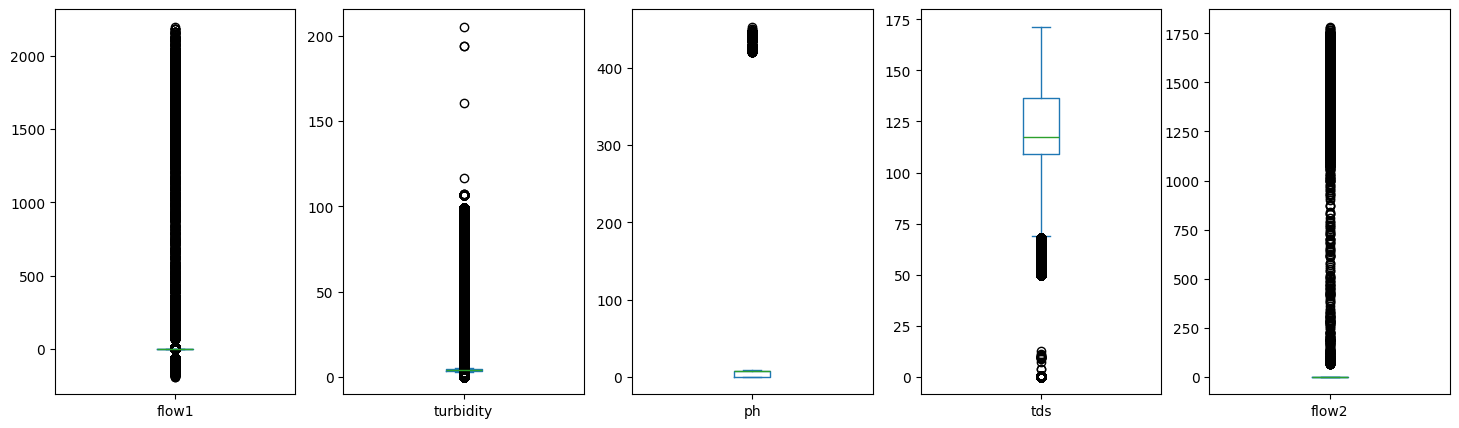

In [ ]:
# Mencari outlier data variabel numerik dengan menggunakan boxplot
float_cols = dfB_clean.select_dtypes(include=['float64']).columns
dfB_clean[float_cols].plot(subplots=True, kind='box', figsize=(18,5))
plt.show()

Sama seperti data panel A, data panel B memiliki outlier di setiap variabel, akan tetapi dalam kasus kualitas air, nilai outlier atau nilai ekstrem memang wajar muncul dan tidak bisa langsung dibuang tanpa alasan yang kuat. Maka, pada kasus ini, outlier tidak dihapus.

#### Target Labeling

In [ ]:
# Fungsi Target
def categorize_water(row):
    pH = row['ph']
    turb = row['turbidity']
    tds = row['tds']
    if (pH < 5.0 or pH > 9.5) and turb > 30 and tds > 1500:
        return 'Cokelat'
    if ((5.0 <= pH < 6.0) or (8.5 <= pH < 9.0)) and (15 <= turb <= 22.5) and (800 <= tds <= 1150):
        return 'Orange'
    if ((6.0 <= pH < 6.5) or (9.0 <= pH < 9.5)) and (22.5 <= turb <= 30) and (1150 <= tds <= 1500):
        return 'Biru'
    if (6.5 <= pH <= 8.0) and turb < 5 and tds < 500:
        return 'Putih'
    return 'Tidak Terdefinisi'

In [ ]:
dfB_clean['quality_label'] = dfB_clean.apply(categorize_water, axis=1)

In [ ]:
dfB_clean['quality_label'] = dfB_clean['quality_label'].replace('Tidak Terdefinisi', 'Non-Putih')
dfB_clean['quality_label'].value_counts()

,count
quality_label,
Putih,1183873
Non-Putih,809528


Setelah target labeling dilakukan, diperoleh dua label target yaitu ‘Putih’ dan ‘Non Putih’. Label ‘Putih’ menunjukkan air memenuhi standar minimal kualitas, sedangkan label Non Putih’ menunjukkan air tidak memenuhi semua syarat kategori dan belum bisa dipastikan layak menurut kriteria yang digunakan.

#### Imbalance Data

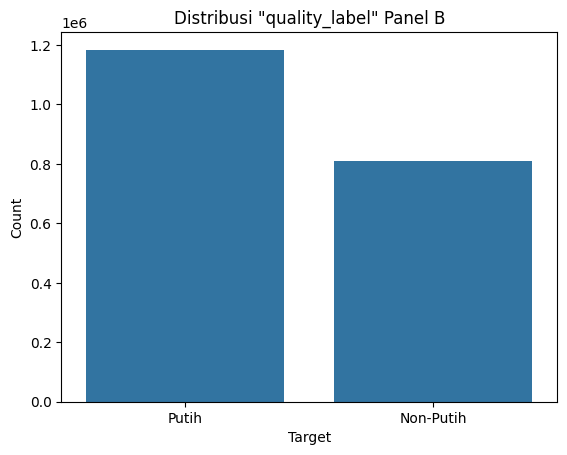

In [ ]:
target_counts = dfB_clean['quality_label'].value_counts()
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('Distribusi "quality_label" Panel B')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

In [ ]:
dfB_clean['quality_label'].value_counts(normalize=True)

,proportion
quality_label,
Putih,0.5939
Non-Putih,0.4061


Data target pada dataset panel B ini sudah cukup seimbang.

#### Data Distribution

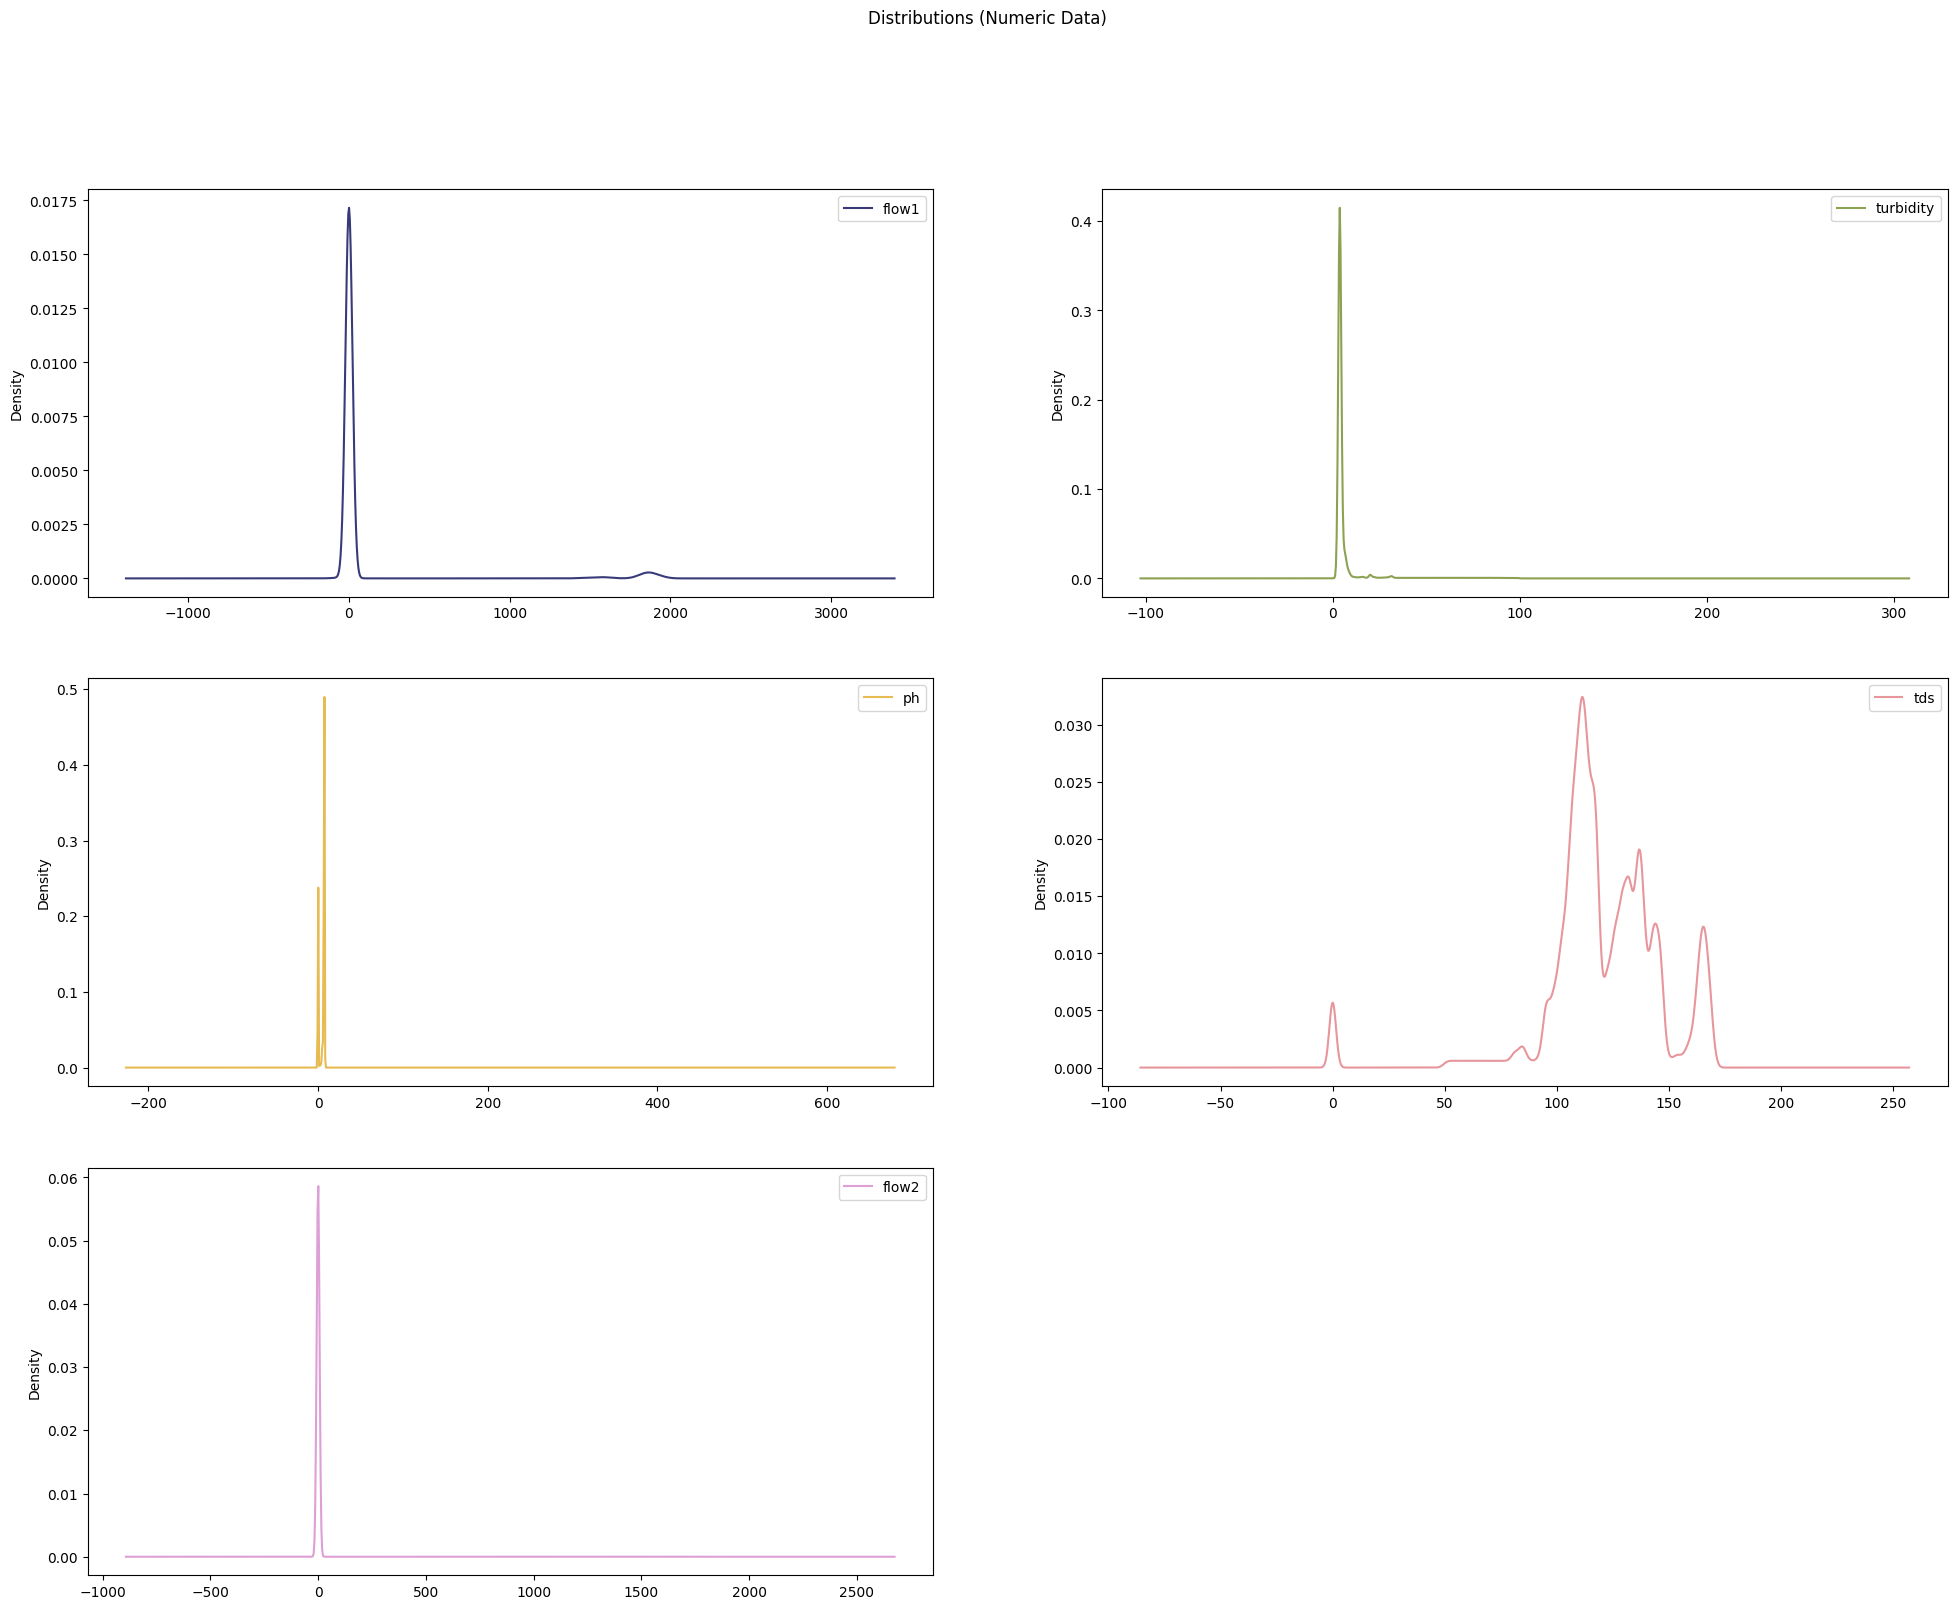

In [ ]:
dfB_clean[['flow1','turbidity','ph','tds','flow2']].plot(
    title = 'Distributions (Numeric Data)',
    kind = 'density',
    subplots = True,
    layout = (3,2),
    sharex = False,
    ylabel = False,
    figsize = (24, 18),
    colormap = 'tab20b')
plt.show()

Seluruh variabel berdistribusi tidak normal.

#### Multivariate Analysis

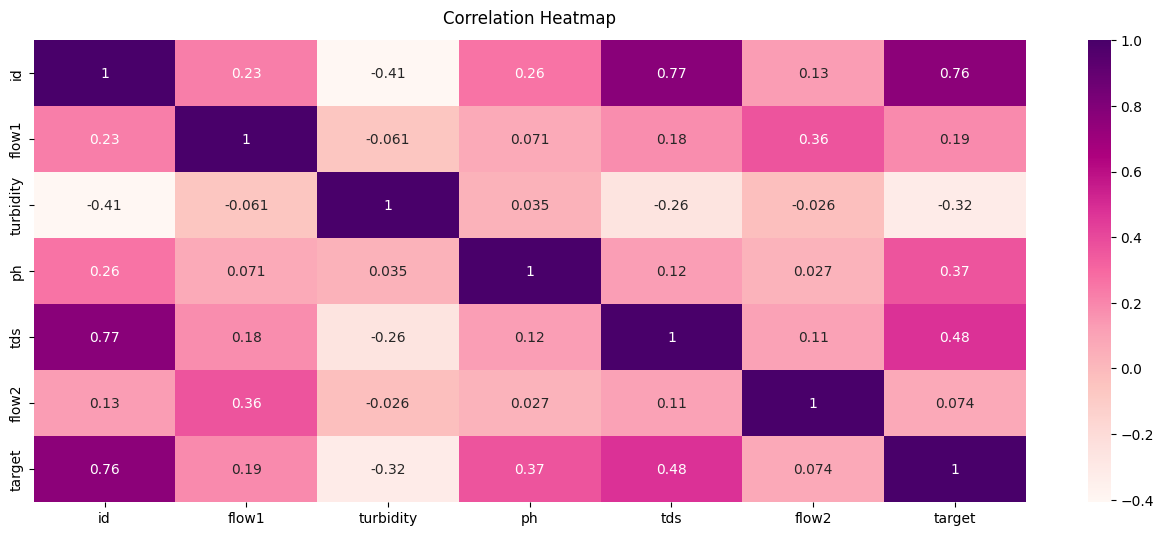

In [ ]:
from sklearn.preprocessing import LabelEncoder

dfB_mulvar = dfB_clean.copy()

# Encode target
le = LabelEncoder()
dfB_mulvar['target'] = le.fit_transform(dfB_mulvar['quality_label'])

# Pilih semua kolom numerik (termasuk yang baru)
numeric_df = dfB_mulvar.select_dtypes(include=['number'])

plt.figure(figsize=(16, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdPu')
plt.title('Correlation Heatmap', fontsize=12, pad=12)
plt.show()

Tidak terdapat korelasi sempurna.

### Machine Learning

#### Import Library

In [ ]:
# Modeling
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost.sklearn import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler

#### Split Data

In [ ]:
dfB_ML = dfB_clean.copy()

# Definisi X dan y
features = ['flow1', 'turbidity', 'tds', 'ph', 'flow2']
X = dfB_ML[features]          # fitur
y = dfB_ML['quality_label']   # target

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)

#Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42)

In [ ]:
import joblib
from google.colab import files

def save_test_data(X_test, y_test_encoded, le):
    y_true_label = le.inverse_transform(y_test_encoded)
    df_test_final = X_test.copy()
    df_test_final['quality_label'] = y_true_label
    data_file_name = 'test_data_B.csv'
    df_test_final.to_csv(data_file_name, index=False)
    print(f"Data Uji berhasil disimpan: {data_file_name}")

save_test_data(X_test, y_test, le)
files.download("test_data_B.csv")

Data Uji berhasil disimpan: test_data_B.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Inisiasi Scaler
scaler = StandardScaler()

# Scaling data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Download scaler
joblib.dump(scaler, "scaler_panelB.joblib")
files.download('scaler_panelB.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Modeling

In [ ]:
# Membuat model
xgb = XGBClassifier(n_jobs=-1,
                    use_label_encoder=False,
                    eval_metric='logloss',
                    random_state=42)
lr = LogisticRegression(solver='saga', max_iter=2000, n_jobs=-1, random_state=42)
sv = LinearSVC(dual=False, max_iter=5000, random_state=42)

# List model
models = [xgb, lr, sv]
model_names = ['XGBoost', 'Logistic Regression', 'SVM']

# Dictionary untuk menyimpan hasil prediksi
y_preds = {}

# Melakukan fit training dan prediksi untuk setiap model
for model, name in zip(models, model_names):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_preds[name] = y_pred

In [ ]:
# Simpan data frame y_pred
df_preds = pd.DataFrame({
    "y_true": y_test
})
for name, preds in y_preds.items():
    df_preds[f"y_pred_{name.replace(' ', '_')}"] = preds
df_preds.head()

,y_true,y_pred_XGBoost,y_pred_Logistic_Regression,y_pred_SVM
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0


In [ ]:
# Simpan model yang sudah di-fit
import joblib

# Dictionary model
model_files = {
    'XGBoost': 'modelB_xgb.joblib',
    'Logistic Regression': 'modelB_lr.joblib',
    'SVM': 'modelB_svm.joblib'
}

# Simpan model sesuai nama
for name, model in zip(model_names, models):
    filename = model_files[name]
    joblib.dump(model, filename)
    print(f"Model {name} saved as {filename}")

Model XGBoost saved as modelB_xgb.joblib
Model Logistic Regression saved as modelB_lr.joblib
Model SVM saved as modelB_svm.joblib


In [ ]:
import shutil

# Buat folder khusus dulu
import os
os.makedirs("saved_modelsB", exist_ok=True)

# Pindahkan semua file model ke folder
for name, filename in model_files.items():
    shutil.move(filename, f"saved_modelsB/{filename}")

# Zip foldernya
shutil.make_archive("models_panelB", 'zip', 'saved_modelsB')

# Download ZIP
from google.colab import files
files.download("models_panelB.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
target_names = le.classes_
results_final = []
print("\n--- ANALISIS KINERJA MODEL ---")

for name, y_pred in y_preds.items():

    # Mendapatkan Laporan Klasifikasi sebagai dictionary
    report = classification_report(y_test, y_pred,
                                   target_names=target_names,
                                   output_dict=True,
                                   zero_division=0) # zero_division=0 agar tidak error jika support 0

    support_values = [report[label]['support'] for label in target_names]
    minority_index = np.argmin(support_values)
    minority_class_label = target_names[minority_index]

    # Menyimpan Metrik Penting
    results_final.append({
        'Model': name,
        'F1-Score (Weighted)': report['weighted avg']['f1-score'],
        f'Recall ({minority_class_label})': report[minority_class_label]['recall'],
        f'Precision ({minority_class_label})': report[minority_class_label]['precision'],
        f'F1-Score ({minority_class_label})': report[minority_class_label]['f1-score']
    })

    # Mencetak laporan detail untuk setiap model
    print(f"\n[Laporan Klasifikasi: {name}]")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


--- ANALISIS KINERJA MODEL ---

[Laporan Klasifikasi: XGBoost]
              precision    recall  f1-score   support

   Non-Putih       1.00      1.00      1.00    161983
       Putih       1.00      1.00      1.00    236698

    accuracy                           1.00    398681
   macro avg       1.00      1.00      1.00    398681
weighted avg       1.00      1.00      1.00    398681


[Laporan Klasifikasi: Logistic Regression]
              precision    recall  f1-score   support

   Non-Putih       1.00      0.97      0.98    161983
       Putih       0.98      1.00      0.99    236698

    accuracy                           0.99    398681
   macro avg       0.99      0.98      0.99    398681
weighted avg       0.99      0.99      0.99    398681


[Laporan Klasifikasi: SVM]
              precision    recall  f1-score   support

   Non-Putih       0.90      0.85      0.87    161983
       Putih       0.90      0.93      0.92    236698

    accuracy                           0.90   

#### Hyperparameter Tuning

In [ ]:
print("Memulai Grid Search untuk XGBoost (Scoring: Accuracy)...")
print("-" * 50)

# Definisi Parameter Grid
# Fokus pada Regularisasi dan Pembatasan Kedalaman (untuk mencegah Overfitting)
param_grid_xgb = {
    # Batasan Wajib untuk mengontrol kompleksitas:
    'max_depth': [3, 5, 7],
    'gamma': [0, 0.5],

    # Kinerja & Regularisasi:
    'learning_rate': [0.05, 0.1],               # Kecepatan pembelajaran
    'n_estimators': [100, 200],                 # Jumlah pohon
    'reg_lambda': [0.1, 1],                     # Regularisasi L2

    # Pengaturan Teknis:
    'n_jobs': [-1],
    'use_label_encoder': [False],
    'eval_metric': ['logloss'],
    'random_state': [42]
}

xgb = XGBClassifier()

# Inisialisasi dan Fitting GridSearchCV XGB
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train_scaled, y_train)

print("\n✅ Hasil Tuning XGBoost Terbaik:")
print("Parameter Terbaik:", grid_search_xgb.best_params_)
print("Akurasi Terbaik:", grid_search_xgb.best_score_)

Memulai Grid Search untuk XGBoost (Scoring: Accuracy)...
--------------------------------------------------
Fitting 3 folds for each of 48 candidates, totalling 144 fits

✅ Hasil Tuning XGBoost Terbaik:
Parameter Terbaik: {'eval_metric': 'logloss', 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'n_jobs': -1, 'random_state': 42, 'reg_lambda': 0.1, 'use_label_encoder': False}
Akurasi Terbaik: 0.9993077155530333


In [ ]:
# Hyperparameter Tuning Logistic Regression

# Parameter Grid
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'max_iter': [1000],
    'random_state': [42]
}

# Inisialisasi Model dan GridSearchCV
lr = LogisticRegression()
grid_search_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fitting
grid_search_lr.fit(X_train_scaled, y_train)

# Hasil Terbaik
print("Parameter Terbaik LR:", grid_search_lr.best_params_)
print("Akurasi Terbaik:", grid_search_lr.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Parameter Terbaik LR: {'C': 100, 'max_iter': 1000, 'random_state': 42}
Akurasi Terbaik: 0.9858602137052273


In [ ]:
# Hyperparameter Tuning SVC Linear

# Parameter Grid
param_grid_svc = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'dual': [False],
    'max_iter': [5000],
    'random_state': [42]
}

# Inisialisasi Model dan GridSearchCV
svc_linear = LinearSVC()
grid_search_svc = GridSearchCV(
    estimator=svc_linear,
    param_grid=param_grid_svc,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fitting
grid_search_svc.fit(X_train_scaled, y_train)

# Hasil Terbaik
print("Parameter Terbaik:", grid_search_svc.best_params_)
print("Akurasi Terbaik", grid_search_svc.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Parameter Terbaik: {'C': 100, 'dual': False, 'max_iter': 5000, 'random_state': 42}
Akurasi Terbaik 0.90093934985452


#### Remodeling

In [ ]:
# Remodeling
xgb_tuned = XGBClassifier(**grid_search_xgb.best_params_)
lr_tuned = LogisticRegression(**grid_search_lr.best_params_)
sv_tuned = LinearSVC(**grid_search_svc.best_params_)

# Fit data train tuned model
xgb_tuned.fit(X_train_scaled, y_train)
lr_tuned.fit(X_train_scaled, y_train)
sv_tuned.fit(X_train_scaled,y_train)

# Pred data test tuned model
y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaled)
y_pred_lr_tuned = lr_tuned.predict(X_test_scaled)
y_pred_svm_tuned = sv_tuned.predict(X_test_scaled)

In [ ]:
import zipfile
from google.colab import files as gfiles

# Buat folder untuk menyimpan model
os.makedirs("tunedB_models", exist_ok=True)

# Simpan model-model tuned
joblib.dump(xgb_tuned, "xgb_tunedB.joblib")
joblib.dump(lr_tuned, "lr_tunedB.joblib")
joblib.dump(sv_tuned, "svm_tunedB.joblib")

model_files_tuned = [
    "xgb_tunedB.joblib",
    "lr_tunedB.joblib",
    "svm_tunedB.joblib"
]

for file in model_files_tuned:
    if os.path.exists(file):
        shutil.copy(file, "tunedB_models")
    else:
        print(f"File tidak ditemukan: {file}")

zip_name = "models_tunedB.zip"
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for root, dirs, files_in_dir in os.walk("tunedB_models"):
        for f in files_in_dir:
            zipf.write(os.path.join(root, f))

In [ ]:
gfiles.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Tambahin ke df_preds
df_preds["y_pred_XGBoost_tuned"] = y_pred_xgb_tuned
df_preds["y_pred_LogisticRegression_tuned"] = y_pred_lr_tuned
df_preds["y_pred_SVM_tuned"] = y_pred_svm_tuned
df_preds.head()

,y_true,y_pred_XGBoost,y_pred_Logistic_Regression,y_pred_SVM,y_pred_XGBoost_tuned,y_pred_LogisticRegression_tuned,y_pred_SVM_tuned
0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0


In [ ]:
from google.colab import files
# Import CSV dan download
df_preds.to_csv('df_predsB.csv', index=False)
files.download('df_predsB.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Evaluasi Keseluruhan

##### Akurasi

In [ ]:
before = [accuracy_score(y_test, y_preds['XGBoost']),
          accuracy_score(y_test, y_preds['Logistic Regression']),
          accuracy_score(y_test, y_preds['SVM'])]
tuned = [accuracy_score(y_test, y_pred_xgb_tuned),
         accuracy_score(y_test, y_pred_lr_tuned),
         accuracy_score(y_test, y_pred_svm_tuned)]

before_formatted = [f'{score:.8f}' for score in before]
tuned_formatted = [f'{score:.8f}' for score in tuned]

acc_df = pd.DataFrame(data={
    'Model Name': model_names,
    'Before Tuning': before_formatted,
    'After Tuning': tuned_formatted
    })

#acc_df.set_index('Model Name', inplace=True)
acc_df

,Model Name,Before Tuning,After Tuning
0,XGBoost,0.99920488,0.99921993
1,Logistic Regression,0.98576305,0.98572041
2,SVM,0.90059220,0.90058969


In [ ]:
# DOwnload
acc_df.to_csv('acc_dfB.csv')
files.download('acc_dfB.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##### Train-Test Evaluation

In [ ]:
import joblib

In [ ]:
# XGB
# Load model
model = joblib.load("/content/tunedB_models/xgb_tunedB.joblib")
a = model.predict(X_train_scaled)
b = model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, a)
test_acc = accuracy_score(y_test, b)

print("XGB Model")
print("Train Accuracy :", train_acc)
print("Test Accuracy  :", test_acc)
print(f"Gap Accuracy : {abs(test_acc-train_acc):.10f}")

XGB Model
Train Accuracy : 0.999265074746664
Test Accuracy  : 0.9992199277116292
Gap Accuracy : 0.0000451470


In [ ]:
# Logistic Regression
# Load model
model = joblib.load("/content/saved_modelsB/modelB_lr.joblib")
a = model.predict(X_train_scaled)
b = model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, a)
test_acc = accuracy_score(y_test, b)

print("Logistic Regression")
print("Train Accuracy :", train_acc)
print("Test Accuracy  :", test_acc)
print(f"Gap Accuracy : {abs(test_acc-train_acc):.10f}")

Logistic Regression
Train Accuracy : 0.985677109461222
Test Accuracy  : 0.9857630536694751
Gap Accuracy : 0.0000859442


In [ ]:
# SVM
# Load model
model = joblib.load("/content/saved_modelsB/modelB_svm.joblib")
a = model.predict(X_train_scaled)
b = model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, a)
test_acc = accuracy_score(y_test, b)

print("SVM")
print("Train Accuracy :", train_acc)
print("Test Accuracy  :", test_acc)
print(f"Gap Accuracy : {abs(test_acc-train_acc):.10f}")

SVM
Train Accuracy : 0.9009123858733822
Test Accuracy  : 0.9005922027886957
Gap Accuracy : 0.0003201831


Tiga model terbaik yang diambil memiliki gap akurasi yang kecil, artinya model tidak mengalami overfitting.

##### Confusion Matrix

In [ ]:
# Membuat classification report
print('XGB Model')
print('### Testing Results Before Tuning ###\n')
print(classification_report(y_test, y_preds['XGBoost'], target_names=target_names), '\n')

print('### Testing Results After Tuning ###\n')
print(classification_report(y_test, y_pred_xgb_tuned, target_names=target_names), '\n')

XGB Model
### Testing Results Before Tuning ###

              precision    recall  f1-score   support

   Non-Putih       1.00      1.00      1.00    161983
       Putih       1.00      1.00      1.00    236698

    accuracy                           1.00    398681
   macro avg       1.00      1.00      1.00    398681
weighted avg       1.00      1.00      1.00    398681
 

### Testing Results After Tuning ###

              precision    recall  f1-score   support

   Non-Putih       1.00      1.00      1.00    161983
       Putih       1.00      1.00      1.00    236698

    accuracy                           1.00    398681
   macro avg       1.00      1.00      1.00    398681
weighted avg       1.00      1.00      1.00    398681
 



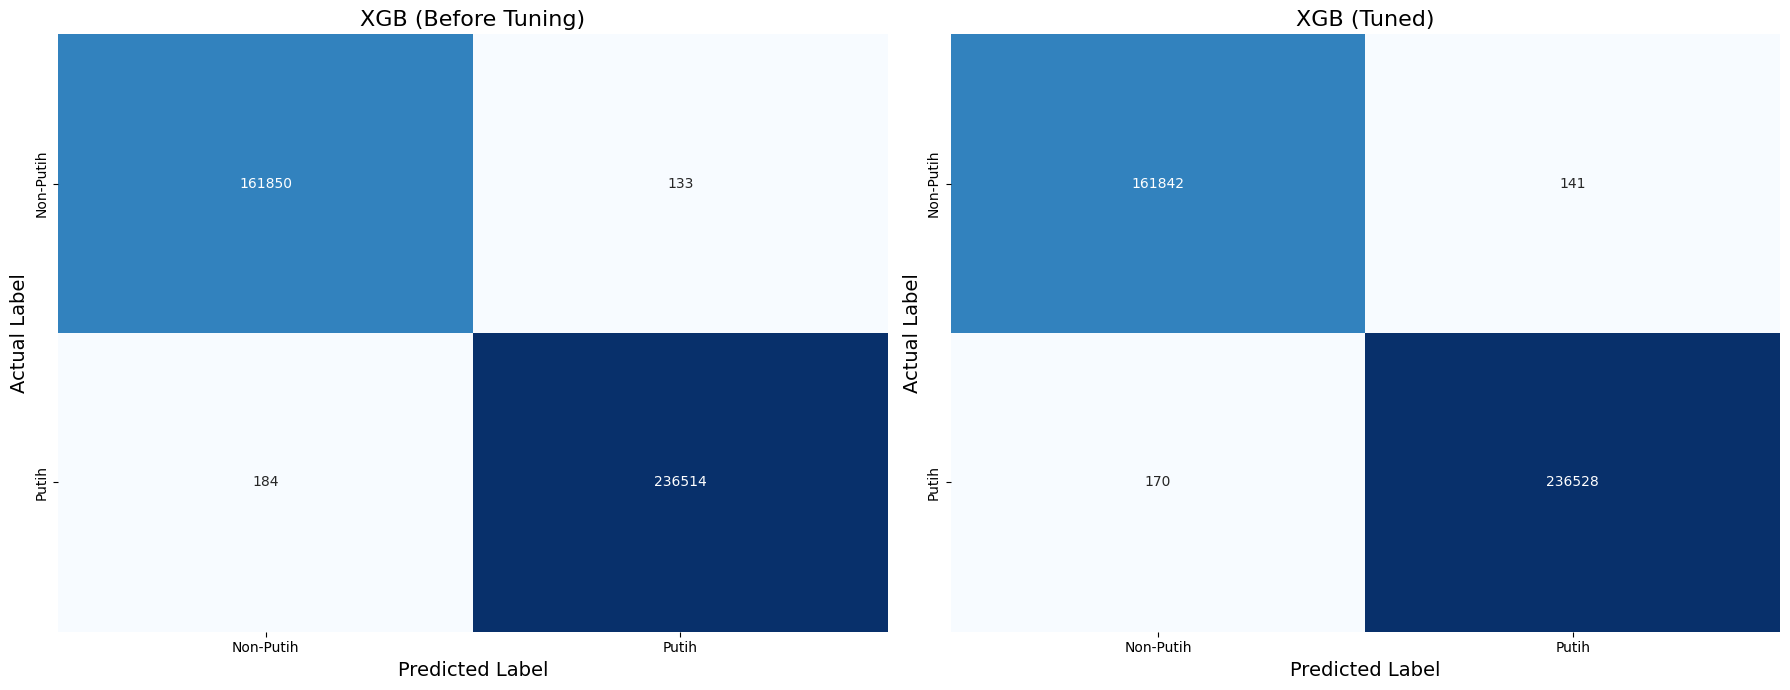

In [ ]:
# Definisikan pasangan model dan prediksi yang baru
model_titles = ['XGB (Before Tuning)', 'XGB (Tuned)']
predictions = [
    y_preds['XGBoost'],
    y_pred_xgb_tuned
]

# Membuat figure dan subplot grid (1 baris, 2 kolom)
fig, axs = plt.subplots(1, 2, figsize=(18, 7))
axs = axs.flatten()

# Iterasi dan plot Confusion Matrices
for i, title in enumerate(model_titles):
    ax = axs[i]
    matrix = confusion_matrix(y_test, predictions[i])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        xticklabels=target_names,
        yticklabels=target_names
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Predicted Label', fontsize=14)
    ax.set_ylabel('Actual Label', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# Membuat classification report
print('Logistic Regression Model')
print('### Testing Results Before Tuning ###\n')
print(classification_report(y_test, y_preds['Logistic Regression'], target_names=target_names), '\n')

print('### Testing Results After Tuning ###\n')
print(classification_report(y_test, y_pred_lr_tuned, target_names=target_names), '\n')

Logistic Regression Model
### Testing Results Before Tuning ###

              precision    recall  f1-score   support

   Non-Putih       1.00      0.97      0.98    161983
       Putih       0.98      1.00      0.99    236698

    accuracy                           0.99    398681
   macro avg       0.99      0.98      0.99    398681
weighted avg       0.99      0.99      0.99    398681
 

### Testing Results After Tuning ###

              precision    recall  f1-score   support

   Non-Putih       1.00      0.97      0.98    161983
       Putih       0.98      1.00      0.99    236698

    accuracy                           0.99    398681
   macro avg       0.99      0.98      0.99    398681
weighted avg       0.99      0.99      0.99    398681
 



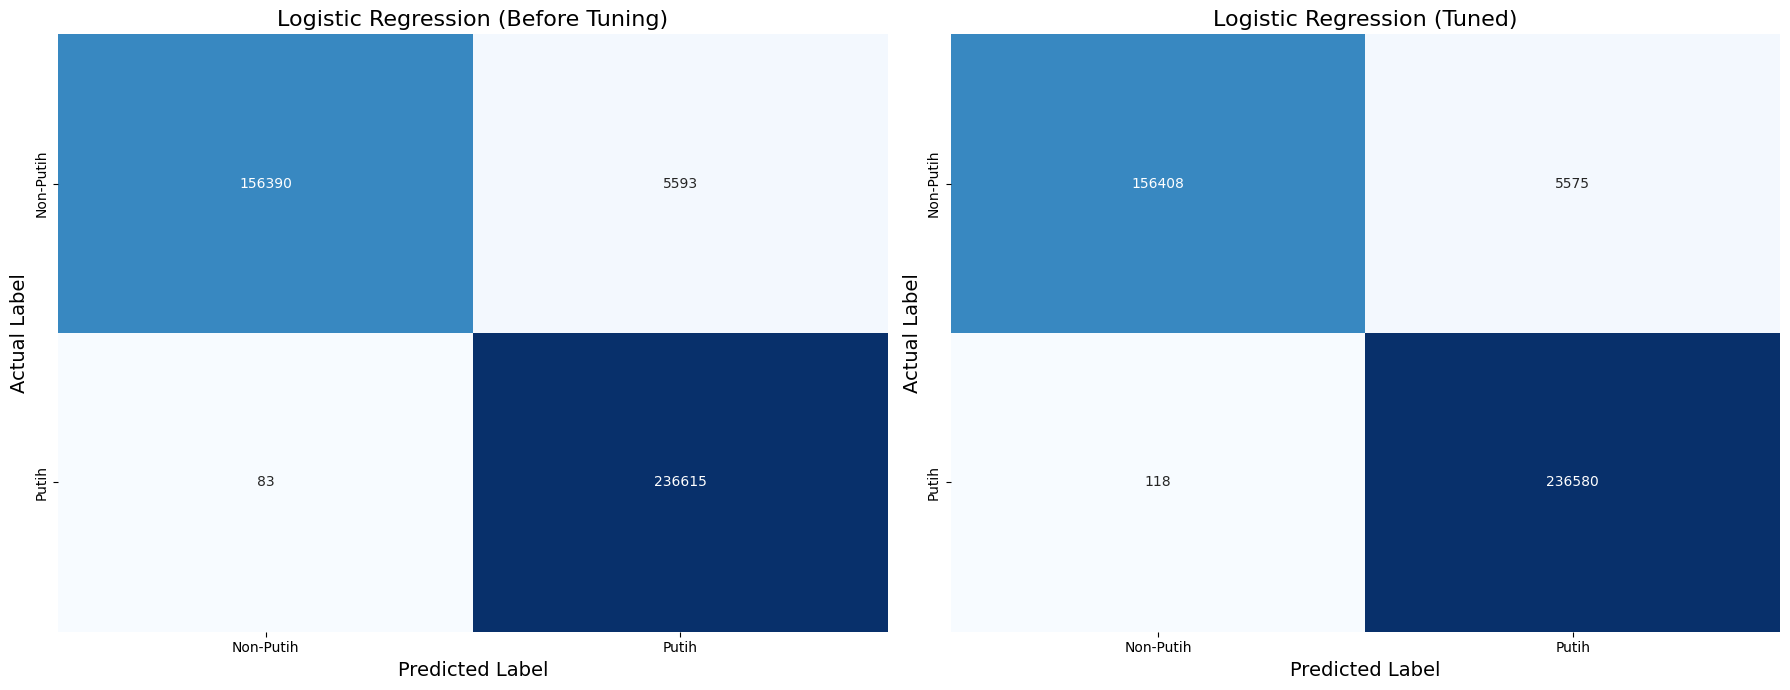

In [ ]:
# Definisikan pasangan model dan prediksi yang baru
model_titles = ['Logistic Regression (Before Tuning)', 'Logistic Regression (Tuned)']
predictions = [
    y_preds['Logistic Regression'],
    y_pred_lr_tuned
]

# Membuat figure dan subplot grid (1 baris, 2 kolom)
fig, axs = plt.subplots(1, 2, figsize=(18, 7))
axs = axs.flatten()

# Iterasi dan plot Confusion Matrices
for i, title in enumerate(model_titles):
    ax = axs[i]
    matrix = confusion_matrix(y_test, predictions[i])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        xticklabels=target_names,
        yticklabels=target_names
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Predicted Label', fontsize=14)
    ax.set_ylabel('Actual Label', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# Membuat classification report
print('SVM Linear Model')
print('### Testing Results Before Tuning ###\n')
print(classification_report(y_test, y_preds['SVM'], target_names=target_names), '\n')

print('### Testing Results After Tuning ###\n')
print(classification_report(y_test, y_pred_svm_tuned, target_names=target_names), '\n')

SVM Linear Model
### Testing Results Before Tuning ###

              precision    recall  f1-score   support

   Non-Putih       0.90      0.85      0.87    161983
       Putih       0.90      0.93      0.92    236698

    accuracy                           0.90    398681
   macro avg       0.90      0.89      0.90    398681
weighted avg       0.90      0.90      0.90    398681
 

### Testing Results After Tuning ###

              precision    recall  f1-score   support

   Non-Putih       0.90      0.85      0.87    161983
       Putih       0.90      0.93      0.92    236698

    accuracy                           0.90    398681
   macro avg       0.90      0.89      0.90    398681
weighted avg       0.90      0.90      0.90    398681
 



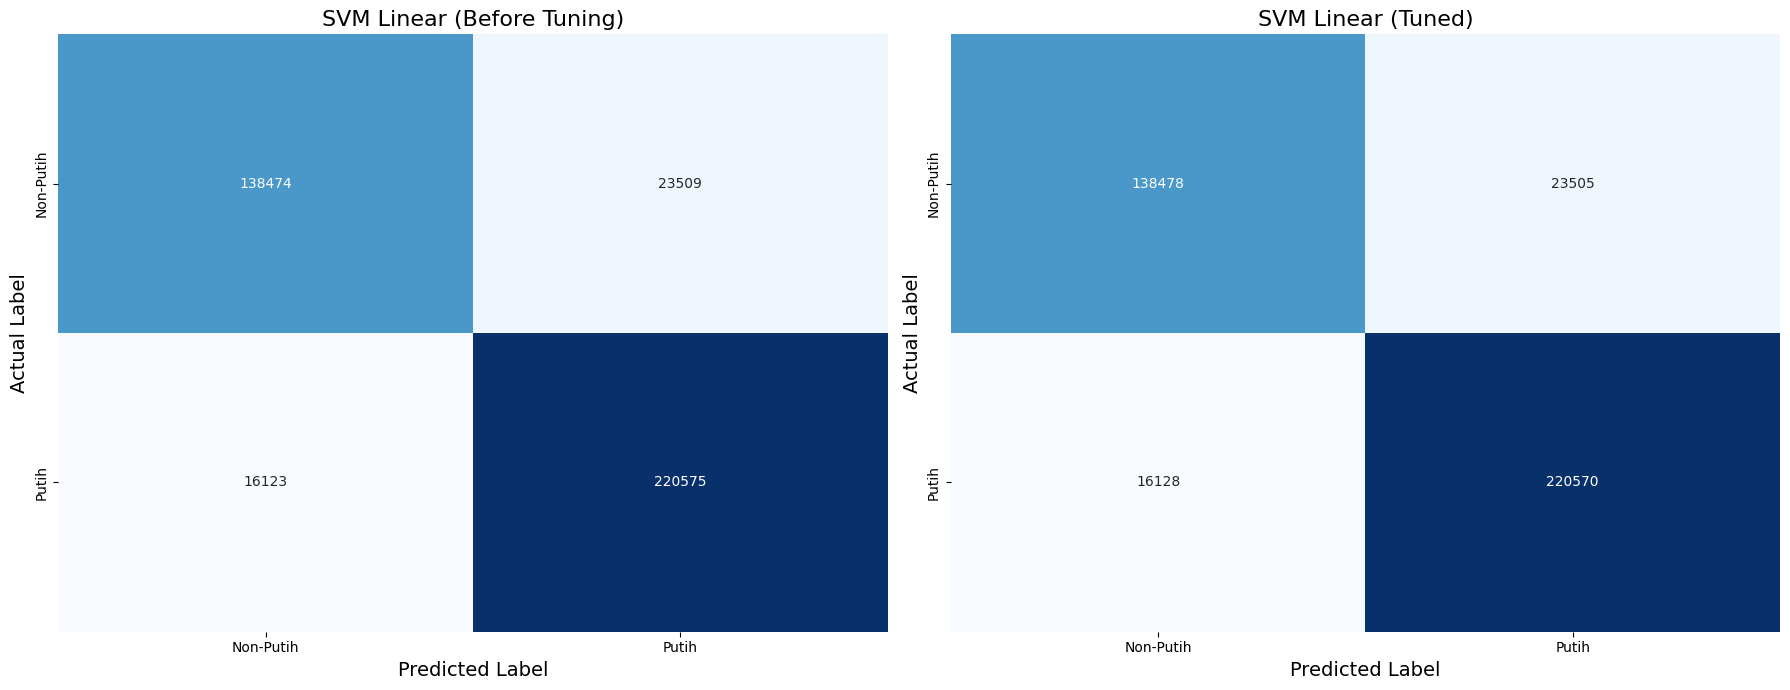

In [ ]:
# Definisikan pasangan model dan prediksi yang baru
model_titles = ['SVM Linear (Before Tuning)', 'SVM Linear (Tuned)']
predictions = [
    y_preds['SVM'],
    y_pred_svm_tuned
]

# Membuat figure dan subplot grid (1 baris, 2 kolom)
fig, axs = plt.subplots(1, 2, figsize=(18, 7))
axs = axs.flatten()

# Iterasi dan plot Confusion Matrices
for i, title in enumerate(model_titles):
    ax = axs[i]
    matrix = confusion_matrix(y_test, predictions[i])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        xticklabels=target_names,
        yticklabels=target_names
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Predicted Label', fontsize=14)
    ax.set_ylabel('Actual Label', fontsize=14)

plt.tight_layout()
plt.show()

XGB After Tuning, LR Before Tuning, SVM Before Tuning

In [ ]:
report_string_XGB = classification_report(y_test, y_preds['XGBoost'], target_names=target_names, output_dict=True)
report_string_LR = classification_report(y_test, y_preds['Logistic Regression'], target_names=target_names, output_dict=True)
report_string_SVM = classification_report(y_test, y_preds['SVM'], target_names=target_names, output_dict=True)
report_string_XGB_tuned = classification_report(y_test, y_pred_xgb_tuned, target_names=target_names, output_dict=True)
report_string_LR_tuned = classification_report(y_test, y_pred_lr_tuned, target_names=target_names, output_dict=True)
report_string_SVM_tuned = classification_report(y_test, y_pred_svm_tuned, target_names=target_names, output_dict=True)

df_report_XGB = pd.DataFrame(report_string_XGB).transpose()
df_report_LR = pd.DataFrame(report_string_LR).transpose()
df_report_SVM = pd.DataFrame(report_string_SVM).transpose()
df_report_XGB_tuned = pd.DataFrame(report_string_XGB_tuned).transpose()
df_report_LR_tuned = pd.DataFrame(report_string_LR_tuned).transpose()
df_report_SVM_tuned = pd.DataFrame(report_string_SVM_tuned).transpose()

df_report_XGB.to_csv('report_XGBB.csv')
df_report_LR.to_csv('report_LRB.csv')
df_report_SVM.to_csv('report_SVMB.csv')
df_report_XGB_tuned.to_csv('report_XGB_tunedB.csv')
df_report_LR_tuned.to_csv('report_LR_tunedB.csv')
df_report_SVM_tuned.to_csv('report_SVM_tunedB.csv')

print("Selesai")

Selesai


In [ ]:
files.download('report_XGBB.csv')
files.download('report_LRB.csv')
files.download('report_SVMB.csv')
files.download('report_XGB_tunedB.csv')
files.download('report_LR_tunedB.csv')
files.download('report_SVM_tunedB.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Kesimpulan

Dipilih model XGB Tuned.